# California Yoga Studio Reviews
## Notebook 5: Topic Modelling (LDA)
*2026-05*

This notebook applies Latent Dirichlet Allocation (LDA) topic modelling
to yoga studio reviews to discover the main themes in customer feedback.
Three separate models are trained on different review subsets to understand
what drives both positive and negative experiences.

**Input:** `yoga_reviews_sentiment.pkl`, `yoga_studios_meta.pkl`
**Output:** `lda_model_all.pkl`, `lda_model_positive.pkl`,
`lda_model_negative.pkl`, `yoga_reviews_topics.pkl`

#Setup

In [ ]:
# install gensim
!pip install gensim

In [ ]:
#install pyLDAvis
!pip install pyLDAvis

In [ ]:
# imports
from google.colab import drive

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore',  category=DeprecationWarning)

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

from collections import Counter
import pickle

import gensim
import gensim.corpora as corpora
from gensim.models import LdaMulticore, CoherenceModel, TfidfModel
from gensim.utils import simple_preprocess, ClippedCorpus
from wordcloud import WordCloud

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

## Load data

In [ ]:
#mount google drive, prepare environment
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

PROJECT_DIR = '/content/gdrive/MyDrive/YogaStudioReviews'

# Load sentiment-enriched reviews
reviews = pd.read_pickle(os.path.join(PROJECT_DIR, 'yoga_reviews_sentiment.pkl'))
yoga_meta = pd.read_pickle(os.path.join(PROJECT_DIR, 'yoga_studios_meta.pkl'))

print(f'Loaded {len(reviews):,} reviews with sentiment scores')
print(f'Positive reviews (4-5 star): {(reviews["rating"] >= 4).sum():,}')
print(f'Negative reviews (1-2 star): {(reviews["rating"] <= 2).sum():,}')

Mounted at /content/gdrive
Loaded 10,547 reviews with sentiment scores
Positive reviews (4-5 star): 10,115
Negative reviews (1-2 star): 324


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Text preprocessing

Before building LDA models, reviews are cleaned and tokenised. Stop words are removed in two stages.

In [ ]:
stop_words = stopwords.words('english')

# Extended stop words and rerun multiple times based on corpus frequency inspection

yoga_stopwords = [
    # Universal yoga/place words
    'yoga', 'studio', 'place', 'studios',
    # Generic positive adjectives
    'great', 'amazing', 'best', 'good', 'nice', 'wonderful', 'beautiful',
    'awesome', 'super',
    # Generic positive verbs
    'love',
    # Function words NLTK missed
    'really', 'also', 'one', 'get', 'much', 'well', 'would', 'like',
    'many', 'better',
    # Activity fillers
    'going', 'try', 'found',
    # Vague feeling words
    'feeling', 'felt',
    # Other fillers
    'always', 'every', 'even', 'still', 'way', 'lot', 'us', 'im', 'ive', 'dont',
    'cant', 'didnt', 'wasnt', 'go', 'make', 'know', 'think',
    'say', 'take', 'come', 'ever', 'since'
]

stop_words.extend(yoga_stopwords)



def preprocess(text):
    tokens = simple_preprocess(str(text), deacc=True)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

print('Preprocessing corpora...')

all_docs      = [preprocess(t) for t in reviews['text']]
positive_docs = [preprocess(t) for t in reviews[reviews['rating'] >= 4]['text']]
negative_docs = [preprocess(t) for t in reviews[reviews['rating'] <= 2]['text']]

print(f'All reviews corpus:      {len(all_docs):,} documents')
print(f'Positive reviews corpus: {len(positive_docs):,} documents')
print(f'Negative reviews corpus: {len(negative_docs):,} documents')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing corpora...
All reviews corpus:      10,547 documents
Positive reviews corpus: 10,115 documents
Negative reviews corpus: 324 documents


In [ ]:
# Find most frequent words across all reviews before stop word decisions
all_words = [word for doc in all_docs for word in doc]
word_freq = Counter(all_words)

print('Top 50 most frequent words in yoga reviews:')
for word, count in word_freq.most_common(50):
    print(f'  {count:>6,}  {word}')

Top 50 most frequent words in yoga reviews:
   4,187  classes
   3,950  class
   2,244  instructors
   2,180  teachers
   1,520  practice
   1,513  staff
   1,511  hot
   1,505  feel
   1,491  clean
   1,415  recommend
   1,381  friendly
   1,374  experience
   1,372  time
   1,074  back
   1,039  body
   1,024  space
   1,016  highly
   1,013  first
     903  new
     893  welcoming
     860  community
     807  people
     763  day
     747  years
     716  work
     714  teacher
     707  definitely
     699  everyone
     662  instructor
     639  different
     635  favorite
     616  workout
     603  variety
     601  room
     600  never
     599  life
     583  helpful
     566  energy
     544  home
     542  knowledgeable
     539  thank
     533  music
     531  massage
     500  sweat
     488  fun
     478  kind
     477  week
     476  excellent
     468  looking
     463  challenging


### Bigram and trigram detection

Multi-word phrases are detected and inspected before corpus building.

In [ ]:
# Build bigrams to inspect before committing to Step 3
bigram = gensim.models.Phrases(all_docs, min_count=10, threshold=50)
bigram_mod = gensim.models.phrases.Phraser(bigram)

trigram = gensim.models.Phrases(bigram[all_docs], min_count=5, threshold=50)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# Apply to all docs
docs_bigrams = [bigram_mod[doc] for doc in all_docs]
docs_trigrams = [trigram_mod[bigram_mod[doc]] for doc in all_docs]

# Find all detected bigrams and trigrams
all_ngrams = [word for doc in docs_trigrams
              for word in doc if '_' in word]
ngram_freq = Counter(all_ngrams)

print('Top 50 most frequent bigrams and trigrams:')
for ngram, count in ngram_freq.most_common(50):
    print(f'  {count:>5,}  {ngram}')

Top 50 most frequent bigrams and trigrams:
    728  highly_recommend
    148  definitely_recommend
    145  san_diego
    144  look_forward
    139  mind_body
    116  front_desk
    102  teacher_training
     90  years_ago
     89  highly_recommended
     86  customer_service
     84  looking_forward
     77  body_brain
     71  santa_monica
     68  top_notch
     60  recommend_anyone
     58  los_angeles
     57  front_desk_staff
     53  life_changing
     53  sense_community
     52  massage_therapist
     50  left_coast
     47  translated_google
     46  away_home
     45  highly_recommend_anyone
     45  enough_things
     45  vinyasa_flow
     45  san_francisco
     45  body_temp
     44  changed_life
     44  months_ago
     44  throughout_day
     44  locker_room
     44  yoni_steam
     43  warm_inviting
     43  high_quality
     41  wide_variety_classes
     41  locker_rooms
     40  frenny_andrew
     39  anywhere_else
     37  pura_vida
     35  physically_mentally
    

## Build corpora

Each corpus is built through four steps:
1. Bigram and trigram detection with ngram stop word filtering
2. Dictionary construction
3. Frequency filtering — terms appearing in fewer than 5 documents
   or more than 85% of documents are removed
4. TF-IDF filtering — terms with TF-IDF score below 0.03 are removed
   to reduce noise from high-frequency low-value words

In [ ]:
# Bigram and trigram specific stop words
ngram_stopwords = {
    'years_ago', 'months_ago', 'look_forward', 'looking_forward',
    'enough_things', 'throughout_day', 'left_coast',
    'translated_google', 'top_notch'
}

def build_corpus(docs):
    # Build bigrams and trigrams
    bigram = gensim.models.Phrases(docs, min_count=10, threshold=50)
    bigram_mod = gensim.models.phrases.Phraser(bigram)

    trigram = gensim.models.Phrases(bigram[docs], min_count=5, threshold=50)
    trigram_mod = gensim.models.phrases.Phraser(trigram)

    # Apply bigrams and trigrams — then filter ngram stop words
    docs_bigrams_trigrams = [
        [token for token in trigram_mod[bigram_mod[doc]]
         if token not in ngram_stopwords]
        for doc in docs
    ]

    # Build dictionary
    id2word = corpora.Dictionary(docs_bigrams_trigrams)

    # Filter extremes
    id2word.filter_extremes(no_below=5, no_above=0.85)

    # Build bag-of-words corpus
    corpus = [id2word.doc2bow(doc) for doc in docs_bigrams_trigrams]

    # Apply TF-IDF filtering
    tfidf = TfidfModel(corpus)
    low_value = 0.03
    filtered_corpus = []
    for bow in corpus:
        tfidf_scores = dict(tfidf[bow])
        filtered_corpus.append([
            (id, freq) for id, freq in bow
            if tfidf_scores.get(id, 0) >= low_value
        ])

    return filtered_corpus, id2word, docs_bigrams_trigrams

print('Building corpora with bigrams and trigrams...')
corpus_all, id2word_all, docs_all_bg = build_corpus(all_docs)
corpus_pos, id2word_pos, docs_pos_bg = build_corpus(positive_docs)
corpus_neg, id2word_neg, docs_neg_bg = build_corpus(negative_docs)

print(f'All corpus vocabulary:      {len(id2word_all):,} terms')
print(f'Positive corpus vocabulary: {len(id2word_pos):,} terms')
print(f'Negative corpus vocabulary: {len(id2word_neg):,} terms')

Building corpora with bigrams and trigrams...
All corpus vocabulary:      4,402 terms
Positive corpus vocabulary: 4,105 terms
Negative corpus vocabulary: 550 terms


**Note on negative corpus vocabulary:** athough full corpus and postive corpus are of healthy size, the negative corpus contains only 295 reviews, resulting in a significantly smaller vocabulary (550 terms vs 4,402 for the full corpus). LDA on this corpus will produce less stable topics — a limitation addressed through rigorous tuning and stability validation below.

## Hyperparameter tuning

LDA performance is sensitive to three key parameters:
- **k** (number of topics) — started the test at 4, 6, 8, 10 and expanded as needed
- **alpha** — controls topic distribution per document; tested:
  symmetric, asymmetric, 0.1, 0.5
- **beta (eta)** — controls word distribution per topic; tested:
  symmetric, 0.1, 0.3, 0.6

Coherence is measured using the **c_v metric**, which correlates
well with human topic interpretability. Each parameter combination
is also later validated on a 75% corpus subset to check stability —
an approach borrowed from my earlier projects.
A coherence difference below 0.03 between full and 75% corpus is
considered fairly stable.

In [ ]:
#coherence function
def compute_coherence(corpus, dictionary, texts, k, a, b):
    model = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=100,
        chunksize=100,
        passes=10,
        alpha=a,
        eta=b
    )
    coherence = CoherenceModel(
        model=model, texts=texts,
        dictionary=dictionary, coherence='c_v'
    )
    return coherence.get_coherence()

# Parameter grid
topics_range = range(4, 12, 2)      # 4, 6, 8, 10
alpha_range  = ['symmetric', 'asymmetric', 0.1, 0.5]
beta_range   = ['symmetric', 0.1, 0.3, 0.6]

### All reviews

In [ ]:
# Tune on ALL reviews corpus
print('Tuning — all reviews corpus...')
results_all = []
for k in topics_range:
    for a in alpha_range:
        for b in beta_range:
            cv = compute_coherence(corpus_all, id2word_all, docs_all_bg, k, a, b)
            results_all.append({'topics': k, 'alpha': a, 'beta': b, 'coherence': cv})
            print(f'  k={k}, alpha={a}, beta={b} → coherence={cv:.4f}')

results_all_df = pd.DataFrame(results_all)
results_all_df.to_csv(os.path.join(PROJECT_DIR, 'lda_tuning_all.csv'), index=False)
best_all = results_all_df.nlargest(1, 'coherence').iloc[0]
print(f'\nBest parameters (all): topics={int(best_all["topics"])}, alpha={best_all["alpha"]}, beta={best_all["beta"]}, coherence={best_all["coherence"]:.4f}')

Tuning — all reviews corpus...
  k=4, alpha=symmetric, beta=symmetric → coherence=0.4389
  k=4, alpha=symmetric, beta=0.1 → coherence=0.4634
  k=4, alpha=symmetric, beta=0.3 → coherence=0.4916
  k=4, alpha=symmetric, beta=0.6 → coherence=0.4935
  k=4, alpha=asymmetric, beta=symmetric → coherence=0.4630
  k=4, alpha=asymmetric, beta=0.1 → coherence=0.4733
  k=4, alpha=asymmetric, beta=0.3 → coherence=0.4621
  k=4, alpha=asymmetric, beta=0.6 → coherence=0.4782
  k=4, alpha=0.1, beta=symmetric → coherence=0.4526
  k=4, alpha=0.1, beta=0.1 → coherence=0.4365
  k=4, alpha=0.1, beta=0.3 → coherence=0.4693
  k=4, alpha=0.1, beta=0.6 → coherence=0.4600
  k=4, alpha=0.5, beta=symmetric → coherence=0.4816
  k=4, alpha=0.5, beta=0.1 → coherence=0.4429
  k=4, alpha=0.5, beta=0.3 → coherence=0.4811
  k=4, alpha=0.5, beta=0.6 → coherence=0.5000
  k=6, alpha=symmetric, beta=symmetric → coherence=0.4532
  k=6, alpha=symmetric, beta=0.1 → coherence=0.4376
  k=6, alpha=symmetric, beta=0.3 → coherence=0.

### All reviews tuning — findings

Beta=0.6 consistently produces the highest coherence across all topic
counts, confirming it as the right parameter for this text type.
Coherence increases from k=4 to k=10, but stability analysis (below)
shows k=10 is sensitive to corpus size — k=8 offers the best balance
of coherence and stability.

In [ ]:
# Quick check — does coherence keep improving beyond k=10?
for k in [12, 14]:
    cv = compute_coherence(corpus_all, id2word_all, docs_all_bg, k, 'symmetric', 0.6)
    print(f'k={k}, alpha=symmetric, beta=0.6 → coherence={cv:.4f}')

k=12, alpha=symmetric, beta=0.6 → coherence=0.4684
k=14, alpha=symmetric, beta=0.6 → coherence=0.5097


In [ ]:
# Validate best parameters on 75% corpus
from gensim.utils import ClippedCorpus

best_params = {'k': 10, 'alpha': 'symmetric', 'beta': 0.6}

num_docs = len(corpus_all)
corpus_75 = ClippedCorpus(corpus_all, int(num_docs * 0.75))

cv_100 = compute_coherence(
    corpus_all, id2word_all, docs_all_bg,
    best_params['k'], best_params['alpha'], best_params['beta']
)
cv_75 = compute_coherence(
    corpus_75, id2word_all, docs_all_bg,
    best_params['k'], best_params['alpha'], best_params['beta']
)

print(f'Best parameters: k={best_params["k"]}, alpha={best_params["alpha"]}, beta={best_params["beta"]}')
print(f'Coherence on 100% corpus: {cv_100:.4f}')
print(f'Coherence on 75% corpus:  {cv_75:.4f}')
print(f'Difference: {abs(cv_100 - cv_75):.4f}')

if abs(cv_100 - cv_75) < 0.02:
    print('Parameters are stable across corpus sizes — robust choice.')
else:
    print('Notable difference — parameters may be sensitive to corpus size.')

Best parameters: k=10, alpha=symmetric, beta=0.6
Coherence on 100% corpus: 0.5356
Coherence on 75% corpus:  0.4697
Difference: 0.0660
Notable difference — parameters may be sensitive to corpus size.


In [ ]:
# Reuse existing tuning results — best params per k with beta=0.6
# Reload tuning results
results_all_df = pd.read_csv(os.path.join(PROJECT_DIR, 'lda_tuning_all.csv'))

# Reuse existing tuning results — best params per k with beta=0.6
best_per_k = (results_all_df[results_all_df['beta'] == '0.6']
              .groupby('topics')
              .apply(lambda x: x.nlargest(1, 'coherence'))
              .reset_index(drop=True))

print('Best parameters per k (beta=0.6):')
print(best_per_k[['topics', 'alpha', 'beta', 'coherence']].to_string(index=False))

# Convert parameter values — keep string if symmetric/asymmetric, else float
def convert_param(value):
    try:
        return float(value)
    except ValueError:
        return value

# Validate on 75% corpus
num_docs = len(corpus_all)
corpus_75 = ClippedCorpus(corpus_all, int(num_docs * 0.75))

print(f'\n{"k":<6} {"alpha":<12} {"100%":<10} {"75%":<10} {"Diff":<10} {"Stable?"}')
print('-' * 55)

for _, row in best_per_k.iterrows():
    k = int(row['topics'])
    a = convert_param(row['alpha'])
    b = convert_param(row['beta'])
    cv_100 = row['coherence']
    cv_75 = compute_coherence(corpus_75, id2word_all, docs_all_bg, k, a, b)
    diff = abs(cv_100 - cv_75)
    stable = 'Yes' if diff < 0.03 else 'No'
    print(f'{k:<6} {str(a):<12} {cv_100:<10.4f} {cv_75:<10.4f} {diff:<10.4f} {stable}')

Best parameters per k (beta=0.6):
 topics      alpha beta  coherence
      4        0.5  0.6   0.500002
      6 asymmetric  0.6   0.505068
      8        0.5  0.6   0.516918
     10  symmetric  0.6   0.530804

k      alpha        100%       75%        Diff       Stable?
-------------------------------------------------------
4      0.5          0.5000     0.4866     0.0134     Yes
6      asymmetric   0.5051     0.4315     0.0736     No
8      0.5          0.5169     0.4915     0.0254     Yes
10     symmetric    0.5308     0.4816     0.0492     No


### Stability validation — all reviews corpus

The best parameters per k are validated on a 75% corpus subset.
k=8 (alpha=0.5, beta=0.6, coherence=0.517) is the optimal choice:
highest coherence among stable configurations (diff=0.025 < 0.03).
k=10 achieves higher coherence but is unstable (diff=0.049), suggesting
1–2 topics may be artefacts of the full corpus rather than genuine themes.

### Positive reviews

In [ ]:
# Tune on POSITIVE reviews corpus
print('Tuning — positive reviews corpus...')
results_pos = []
for k in topics_range:
    for a in alpha_range:
        for b in beta_range:
            cv = compute_coherence(corpus_pos, id2word_pos, docs_pos_bg, k, a, b)
            results_pos.append({'topics': k, 'alpha': a, 'beta': b, 'coherence': cv})
            print(f'  k={k}, alpha={a}, beta={b} → coherence={cv:.4f}')

results_pos_df = pd.DataFrame(results_pos)
results_pos_df.to_csv(os.path.join(PROJECT_DIR, 'lda_tuning_positive.csv'), index=False)
best_pos = results_pos_df.nlargest(1, 'coherence').iloc[0]
print(f'\nBest parameters (positive): topics={int(best_pos["topics"])}, alpha={best_pos["alpha"]}, beta={best_pos["beta"]}, coherence={best_pos["coherence"]:.4f}')

Tuning — positive reviews corpus...
  k=4, alpha=symmetric, beta=symmetric → coherence=0.4618
  k=4, alpha=symmetric, beta=0.1 → coherence=0.4699
  k=4, alpha=symmetric, beta=0.3 → coherence=0.4763
  k=4, alpha=symmetric, beta=0.6 → coherence=0.4967
  k=4, alpha=asymmetric, beta=symmetric → coherence=0.4047
  k=4, alpha=asymmetric, beta=0.1 → coherence=0.4268
  k=4, alpha=asymmetric, beta=0.3 → coherence=0.3985
  k=4, alpha=asymmetric, beta=0.6 → coherence=0.4619
  k=4, alpha=0.1, beta=symmetric → coherence=0.4549
  k=4, alpha=0.1, beta=0.1 → coherence=0.4467
  k=4, alpha=0.1, beta=0.3 → coherence=0.4579
  k=4, alpha=0.1, beta=0.6 → coherence=0.4781
  k=4, alpha=0.5, beta=symmetric → coherence=0.4576
  k=4, alpha=0.5, beta=0.1 → coherence=0.4548
  k=4, alpha=0.5, beta=0.3 → coherence=0.4606
  k=4, alpha=0.5, beta=0.6 → coherence=0.4785
  k=6, alpha=symmetric, beta=symmetric → coherence=0.4561
  k=6, alpha=symmetric, beta=0.1 → coherence=0.4538
  k=6, alpha=symmetric, beta=0.3 → coheren

### Positive reviews tuning — findings

Beta=0.6 dominates again. Coherence peaks at k=6 (0.5278) and drops
at higher topic counts — unlike the full corpus, positive reviews
cluster naturally into fewer themes. k=6 is both the highest-coherence
and a stable configuration (diff=0.020).

In [ ]:
# Load positive tuning results and run stability check
results_pos_df = pd.read_csv(os.path.join(PROJECT_DIR, 'lda_tuning_positive.csv'))

best_per_k_pos = (results_pos_df[results_pos_df['beta'] == '0.6']
                  .groupby('topics')
                  .apply(lambda x: x.nlargest(1, 'coherence'))
                  .reset_index(drop=True))

print('Best parameters per k (beta=0.6) — positive corpus:')
print(best_per_k_pos[['topics', 'alpha', 'beta', 'coherence']].to_string(index=False))

# Validate on 75% corpus
num_docs_pos = len(corpus_pos)
corpus_pos_75 = ClippedCorpus(corpus_pos, int(num_docs_pos * 0.75))

print(f'\n{"k":<6} {"alpha":<12} {"100%":<10} {"75%":<10} {"Diff":<10} {"Stable?"}')
print('-' * 55)

for _, row in best_per_k_pos.iterrows():
    k = int(row['topics'])
    a = convert_param(row['alpha'])
    b = convert_param(row['beta'])
    cv_100 = row['coherence']
    cv_75 = compute_coherence(corpus_pos_75, id2word_pos, docs_pos_bg, k, a, b)
    diff = abs(cv_100 - cv_75)
    stable = 'Yes' if diff < 0.03 else 'No'
    print(f'{k:<6} {str(a):<12} {cv_100:<10.4f} {cv_75:<10.4f} {diff:<10.4f} {stable}')

Best parameters per k (beta=0.6) — positive corpus:
 topics     alpha beta  coherence
      4 symmetric  0.6   0.496707
      6       0.1  0.6   0.527819
      8       0.5  0.6   0.499137
     10       0.5  0.6   0.489770

k      alpha        100%       75%        Diff       Stable?
-------------------------------------------------------
4      symmetric    0.4967     0.5354     0.0387     No
6      0.1          0.5278     0.5075     0.0203     Yes
8      0.5          0.4991     0.5101     0.0109     Yes
10     0.5          0.4898     0.4977     0.0079     Yes


### Stability validation — positive reviews corpus

k=6 (alpha=0.1, beta=0.6) is confirmed as optimal: highest coherence
among stable models, consistent across corpus sizes. k=4 is unusually
unstable — the 75% corpus outperforms the full corpus, suggesting the
model overfits to noise in the full positive corpus when forced into
only 4 buckets.

### Negative reviews

In [ ]:
# Tune on NEGATIVE reviews corpus
print('Tuning — negative reviews corpus...')
results_neg = []
for k in topics_range:
    for a in alpha_range:
        for b in beta_range:
            cv = compute_coherence(corpus_neg, id2word_neg, docs_neg_bg, k, a, b)
            results_neg.append({'topics': k, 'alpha': a, 'beta': b, 'coherence': cv})
            print(f'  k={k}, alpha={a}, beta={b} → coherence={cv:.4f}')

results_neg_df = pd.DataFrame(results_neg)
results_neg_df.to_csv(os.path.join(PROJECT_DIR, 'lda_tuning_negative.csv'), index=False)
best_neg = results_neg_df.nlargest(1, 'coherence').iloc[0]
print(f'\nBest parameters (negative): topics={int(best_neg["topics"])}, alpha={best_neg["alpha"]}, beta={best_neg["beta"]}, coherence={best_neg["coherence"]:.4f}')

Tuning — negative reviews corpus...
  k=4, alpha=symmetric, beta=symmetric → coherence=0.2528
  k=4, alpha=symmetric, beta=0.1 → coherence=0.2441
  k=4, alpha=symmetric, beta=0.3 → coherence=0.2602
  k=4, alpha=symmetric, beta=0.6 → coherence=0.2996
  k=4, alpha=asymmetric, beta=symmetric → coherence=0.3040
  k=4, alpha=asymmetric, beta=0.1 → coherence=0.2961
  k=4, alpha=asymmetric, beta=0.3 → coherence=0.3043
  k=4, alpha=asymmetric, beta=0.6 → coherence=0.2862
  k=4, alpha=0.1, beta=symmetric → coherence=0.2615
  k=4, alpha=0.1, beta=0.1 → coherence=0.2715
  k=4, alpha=0.1, beta=0.3 → coherence=0.2674
  k=4, alpha=0.1, beta=0.6 → coherence=0.3064
  k=4, alpha=0.5, beta=symmetric → coherence=0.2580
  k=4, alpha=0.5, beta=0.1 → coherence=0.2656
  k=4, alpha=0.5, beta=0.3 → coherence=0.2578
  k=4, alpha=0.5, beta=0.6 → coherence=0.2632
  k=6, alpha=symmetric, beta=symmetric → coherence=0.2408
  k=6, alpha=symmetric, beta=0.1 → coherence=0.2444
  k=6, alpha=symmetric, beta=0.3 → coheren

### Negative reviews tuning — findings

The negative corpus (295 reviews) produces substantially lower coherence
scores than the other two corpora (best: 0.3607 vs 0.5278 for positive).
Beta=0.6 no longer dominates — the pattern is scattered, itself a signal
of instability driven by corpus size. The apparent winner (k=8,
asymmetric, beta=0.3, coherence=0.3607) is validated below.

In [ ]:
# Check k=3 for negative corpus only
for a in ['asymmetric', 0.1, 0.5]:
    for b in [0.3, 0.6]:
        cv = compute_coherence(corpus_neg, id2word_neg, docs_neg_bg, 3, a, b)
        print(f'k=3, alpha={a}, beta={b} → coherence={cv:.4f}')

k=3, alpha=asymmetric, beta=0.3 → coherence=0.2863
k=3, alpha=asymmetric, beta=0.6 → coherence=0.2737
k=3, alpha=0.1, beta=0.3 → coherence=0.2544
k=3, alpha=0.1, beta=0.6 → coherence=0.2519
k=3, alpha=0.5, beta=0.3 → coherence=0.2591
k=3, alpha=0.5, beta=0.6 → coherence=0.2593


In [ ]:
results_neg_df = pd.read_csv(os.path.join(PROJECT_DIR, 'lda_tuning_negative.csv'))

# For negative corpus check all best per k regardless of beta
# since beta=0.6 doesn't dominate here
best_per_k_neg = (results_neg_df
                  .groupby('topics')
                  .apply(lambda x: x.nlargest(1, 'coherence'))
                  .reset_index(drop=True))

print('Best parameters per k — negative corpus:')
print(best_per_k_neg[['topics', 'alpha', 'beta', 'coherence']].to_string(index=False))

# Validate on 75% corpus
num_docs_neg = len(corpus_neg)
corpus_neg_75 = ClippedCorpus(corpus_neg, int(num_docs_neg * 0.75))

print(f'\n{"k":<6} {"alpha":<12} {"beta":<8} {"100%":<10} {"75%":<10} {"Diff":<10} {"Stable?"}')
print('-' * 65)

for _, row in best_per_k_neg.iterrows():
    k = int(row['topics'])
    a = convert_param(row['alpha'])
    b = convert_param(row['beta'])
    cv_100 = row['coherence']
    cv_75 = compute_coherence(corpus_neg_75, id2word_neg, docs_neg_bg, k, a, b)
    diff = abs(cv_100 - cv_75)
    stable = 'Yes' if diff < 0.03 else 'No'
    print(f'{k:<6} {str(a):<12} {str(b):<8} {cv_100:<10.4f} {cv_75:<10.4f} {diff:<10.4f} {stable}')

Best parameters per k — negative corpus:
 topics      alpha beta  coherence
      4        0.1  0.6   0.306365
      6 asymmetric  0.3   0.286090
      8 asymmetric  0.3   0.360704
     10 asymmetric  0.3   0.351142

k      alpha        beta     100%       75%        Diff       Stable?
-----------------------------------------------------------------
4      0.1          0.6      0.3064     0.3068     0.0005     Yes
6      asymmetric   0.3      0.2861     0.3505     0.0645     No
8      asymmetric   0.3      0.3607     0.3663     0.0056     Yes
10     asymmetric   0.3      0.3511     0.3582     0.0071     Yes


### Stability validation — negative reviews corpus

k=8 (asymmetric, beta=0.3) is confirmed stable (diff=0.006) and
achieves the highest coherence. However, pyLDAvis inspection reveals
topic overlap — Topics 6 and 8 fall inside Topic 1, and Topic 7 inside
Topic 2 — indicating topic fragmentation. k=4 (alpha=0.1, beta=0.6)
is selected instead as it produces well-separated topics in pyLDAvis
while remaining stable (diff=0.010).

**Limitation:** the negative review corpus contains only 295 documents, which is small for LDA topic modelling. The best coherence score achieved (0.3607) is notably lower than the positive (0.5278) and full corpus (0.5169), indicating less stable topic separation. Negative review topics should be interpreted with caution and treated as indicative rather than definitive.

## Final models

### Parameter summary

| Corpus | k | alpha | beta | c_v coherence | Stable? |
|--------|---|-------|------|---------------|---------|
| All reviews | 8 | 0.5 | 0.6 | 0.517 | ✅ Yes |
| Positive (4-5★) | 6 | 0.1 | 0.6 | 0.528 | ✅ Yes |
| Negative (1-2★) | 4 | 0.1 | 0.6 | 0.317 | ✅ Yes |

Final models use `passes=15` for more thorough convergence.
u_mass coherence is reported for the final models — note that u_mass
always produces negative values; scores closer to 0 indicate better fit.

In [ ]:
# Final model parameters
PARAMS = {
    'all':      {'k': 8,  'alpha': 0.5,         'beta': 0.6},
    'positive': {'k': 6,  'alpha': 0.1,          'beta': 0.6},
    'negative': {'k': 8,  'alpha': 'asymmetric', 'beta': 0.3}
}

def build_final_model(corpus, id2word, params, label):
    print(f'Training {label} model (k={params["k"]})...')
    model = LdaMulticore(
        corpus=corpus,
        id2word=id2word,
        num_topics=params['k'],
        alpha=params['alpha'],
        eta=params['beta'],
        random_state=100,
        chunksize=100,
        passes=15,
        workers=2
    )
    # Final coherence score
    coherence = CoherenceModel(
        model=model,
        corpus=corpus,
        dictionary=id2word,
        coherence='u_mass'
    ).get_coherence()
    print(f'  Done. u_mass coherence: {coherence:.4f}')
    return model

model_all = build_final_model(corpus_all, id2word_all, PARAMS['all'], 'all reviews')
model_pos = build_final_model(corpus_pos, id2word_pos, PARAMS['positive'], 'positive reviews')
model_neg = build_final_model(corpus_neg, id2word_neg, PARAMS['negative'], 'negative reviews')

Training all reviews model (k=8)...
  Done. u_mass coherence: -3.1025
Training positive reviews model (k=6)...
  Done. u_mass coherence: -2.7447
Training negative reviews model (k=8)...
  Done. u_mass coherence: -4.7101


**Note** I used passes=15 instead of 10 for the final models — more passes means the model converges more thoroughly. Also switched to u_mass coherence for the final score since it's faster to compute and standard for reporting final model quality.

Score meaning:

- All reviews (-3.10) — moderate, consistent with c_v of 0.52
- Positive (-2.74) — acceptable to good, best model
- Negative (-4.71) — weak, consistent with the low c_v we saw during tuning and the small corpus size

## Topic visualisation — pyLDAvis

The interactive pyLDAvis visualisation shows topic separation and
prevalence. Well-separated bubbles with minimal overlap indicate
distinct, meaningful topics. Bubble size reflects topic prevalence
across the corpus.

In [ ]:
pyLDAvis.enable_notebook()

# All reviews
vis_all = gensimvis.prepare(model_all, corpus_all, id2word_all)
pyLDAvis.display(vis_all)

In [ ]:
# Positive reviews
vis_pos = gensimvis.prepare(model_pos, corpus_pos, id2word_pos)
pyLDAvis.display(vis_pos)

In [ ]:
# Negative reviews
vis_neg = gensimvis.prepare(model_neg, corpus_neg, id2word_neg)
pyLDAvis.display(vis_neg)

Since the visualisation for the negative corpus shows significant topic overlap, a better model was tested for a rebuild.

In [ ]:
# Test k=4 and k=5 for negative corpus with best alpha/beta
print('Testing k=4 and k=5 for negative corpus...')

for k in [4, 5]:
    # Test best params from tuning (asymmetric, beta=0.3)
    cv = compute_coherence(corpus_neg, id2word_neg, docs_neg_bg, k, 'asymmetric', 0.3)
    # Also validate on 75%
    cv_75 = compute_coherence(corpus_neg_75, id2word_neg, docs_neg_bg, k, 'asymmetric', 0.3)
    diff = abs(cv - cv_75)
    print(f'k={k}: coherence={cv:.4f} | 75%={cv_75:.4f} | diff={diff:.4f} | stable={"Yes" if diff < 0.03 else "No"}')

    # Also try alpha=0.1 since it won for k=4 earlier
    cv2 = compute_coherence(corpus_neg, id2word_neg, docs_neg_bg, k, 0.1, 0.6)
    cv2_75 = compute_coherence(corpus_neg_75, id2word_neg, docs_neg_bg, k, 0.1, 0.6)
    diff2 = abs(cv2 - cv2_75)
    print(f'k={k} (alpha=0.1, beta=0.6): coherence={cv2:.4f} | 75%={cv2_75:.4f} | diff={diff2:.4f} | stable={"Yes" if diff2 < 0.03 else "No"}')
    print()

Testing k=4 and k=5 for negative corpus...
k=4: coherence=0.2912 | 75%=0.3399 | diff=0.0487 | stable=No
k=4 (alpha=0.1, beta=0.6): coherence=0.3174 | 75%=0.3073 | diff=0.0101 | stable=Yes

k=5: coherence=0.3223 | 75%=0.2876 | diff=0.0348 | stable=No
k=5 (alpha=0.1, beta=0.6): coherence=0.2567 | 75%=0.2475 | diff=0.0092 | stable=Yes



In [ ]:
model_neg = LdaMulticore(
    corpus=corpus_neg,
    id2word=id2word_neg,
    num_topics=4,
    alpha=0.1,
    eta=0.6,
    random_state=100,
    chunksize=100,
    passes=15,
    workers=2
)

# Check final coherence
coherence_neg = CoherenceModel(
    model=model_neg,
    corpus=corpus_neg,
    dictionary=id2word_neg,
    coherence='u_mass'
).get_coherence()

print(f'Negative model rebuilt: k=4, u_mass coherence={coherence_neg:.4f}')

# Check pyLDAvis
vis_neg = gensimvis.prepare(model_neg, corpus_neg, id2word_neg)
pyLDAvis.display(vis_neg)

Negative model rebuilt: k=4, u_mass coherence=-3.7057


New negative model reflects a better grasp of the topics.

## Topic wordclouds

Word size in each cloud is proportional to the word's weight in that
topic — the most defining words appear largest.

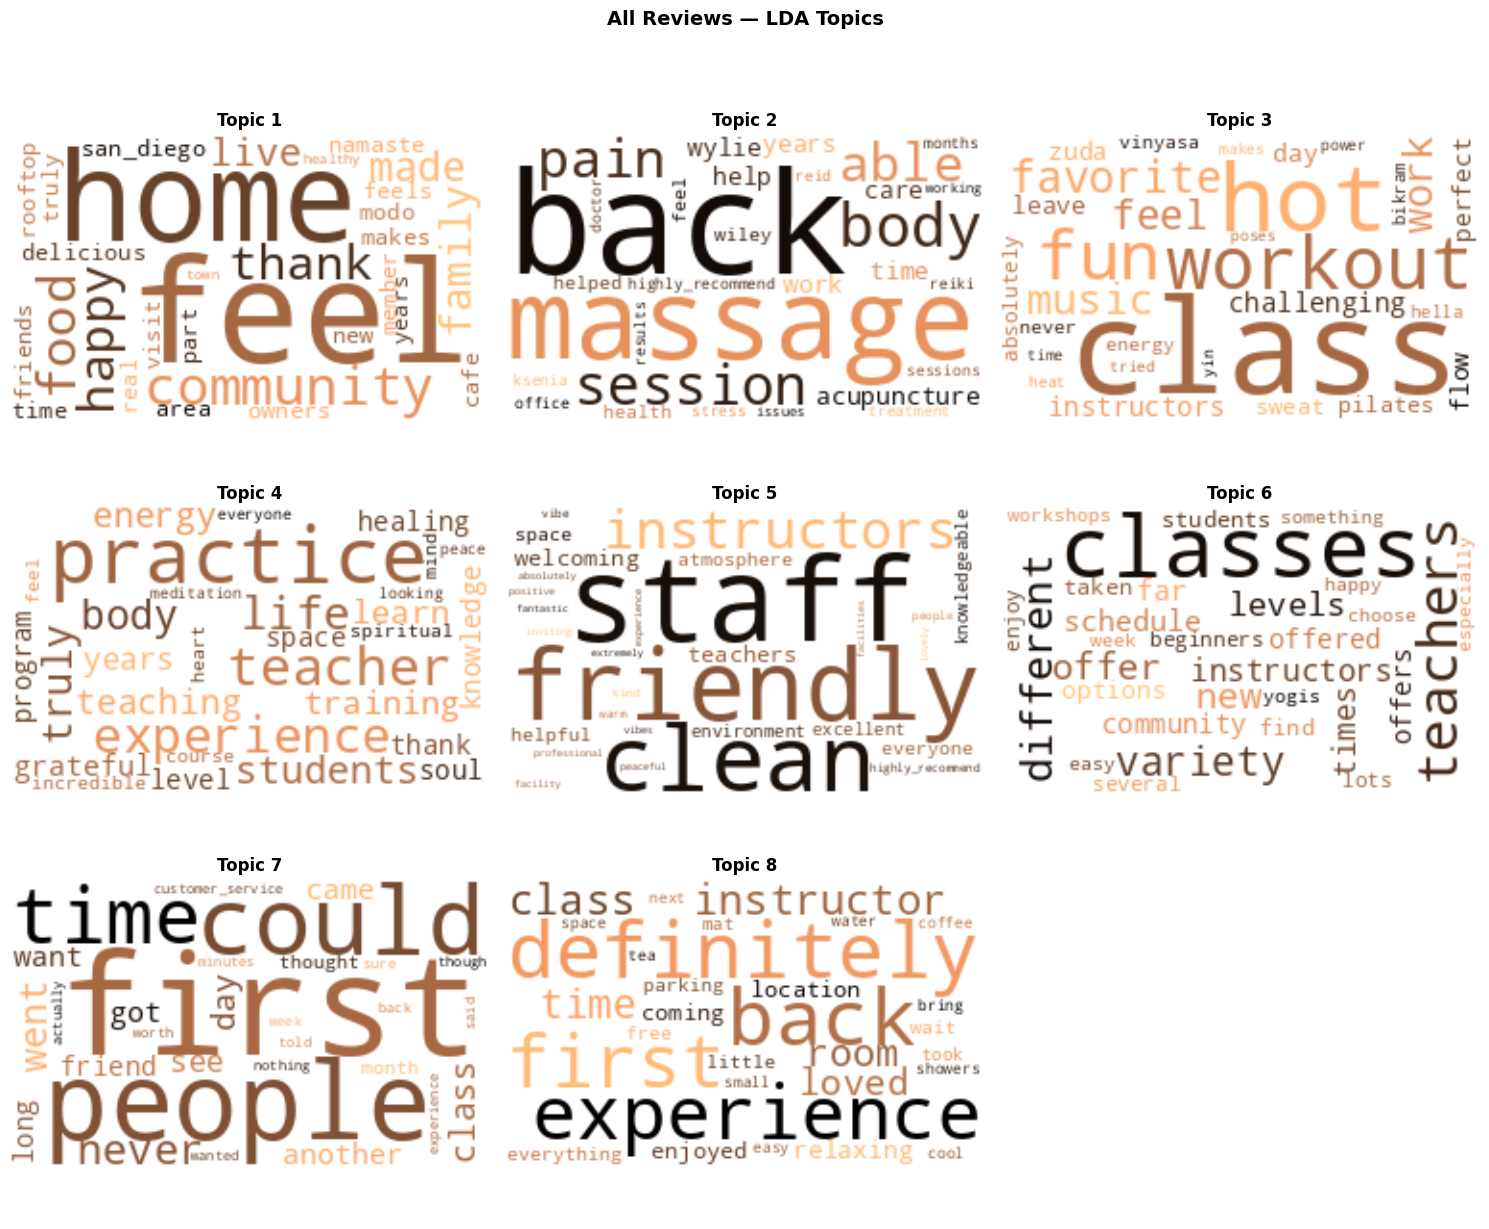

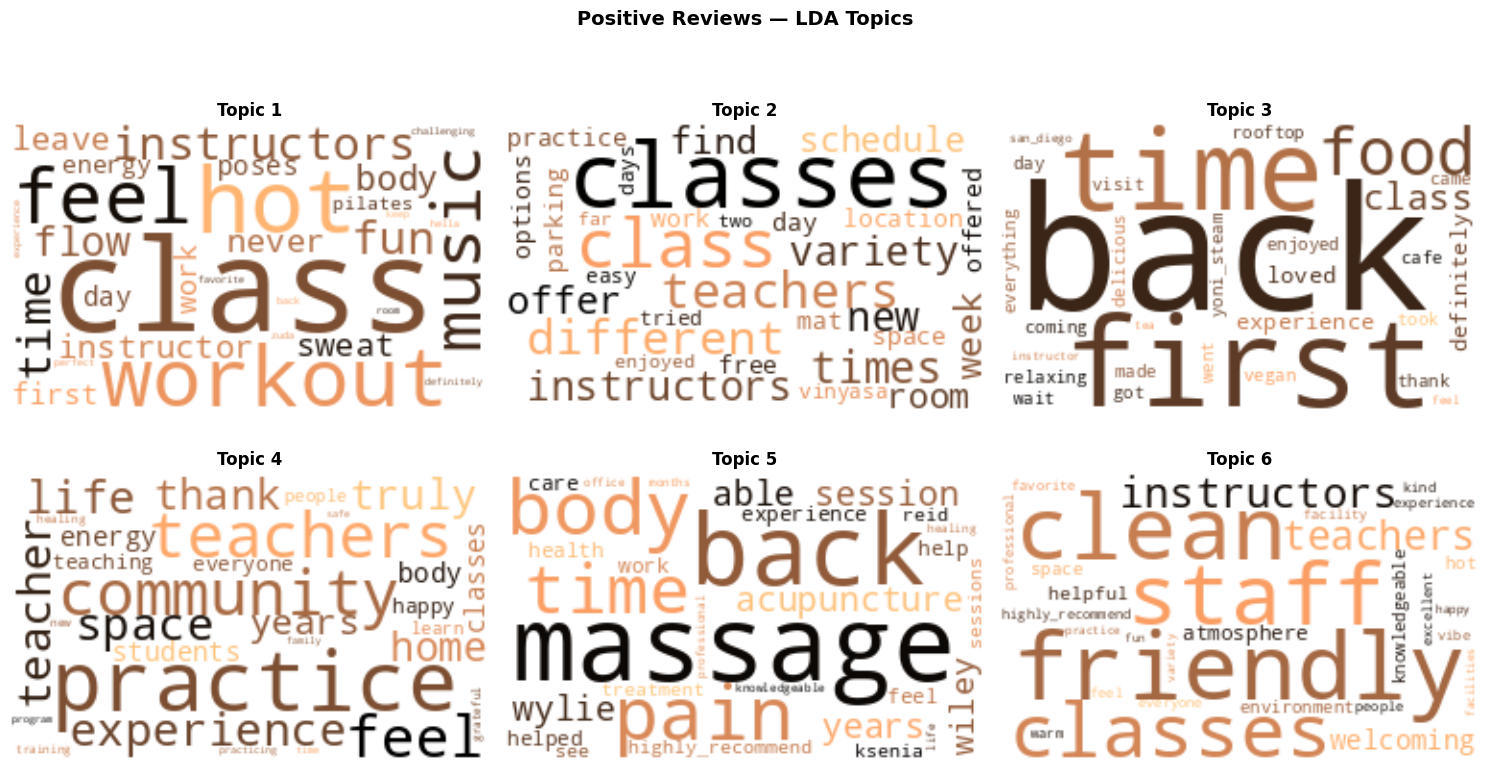

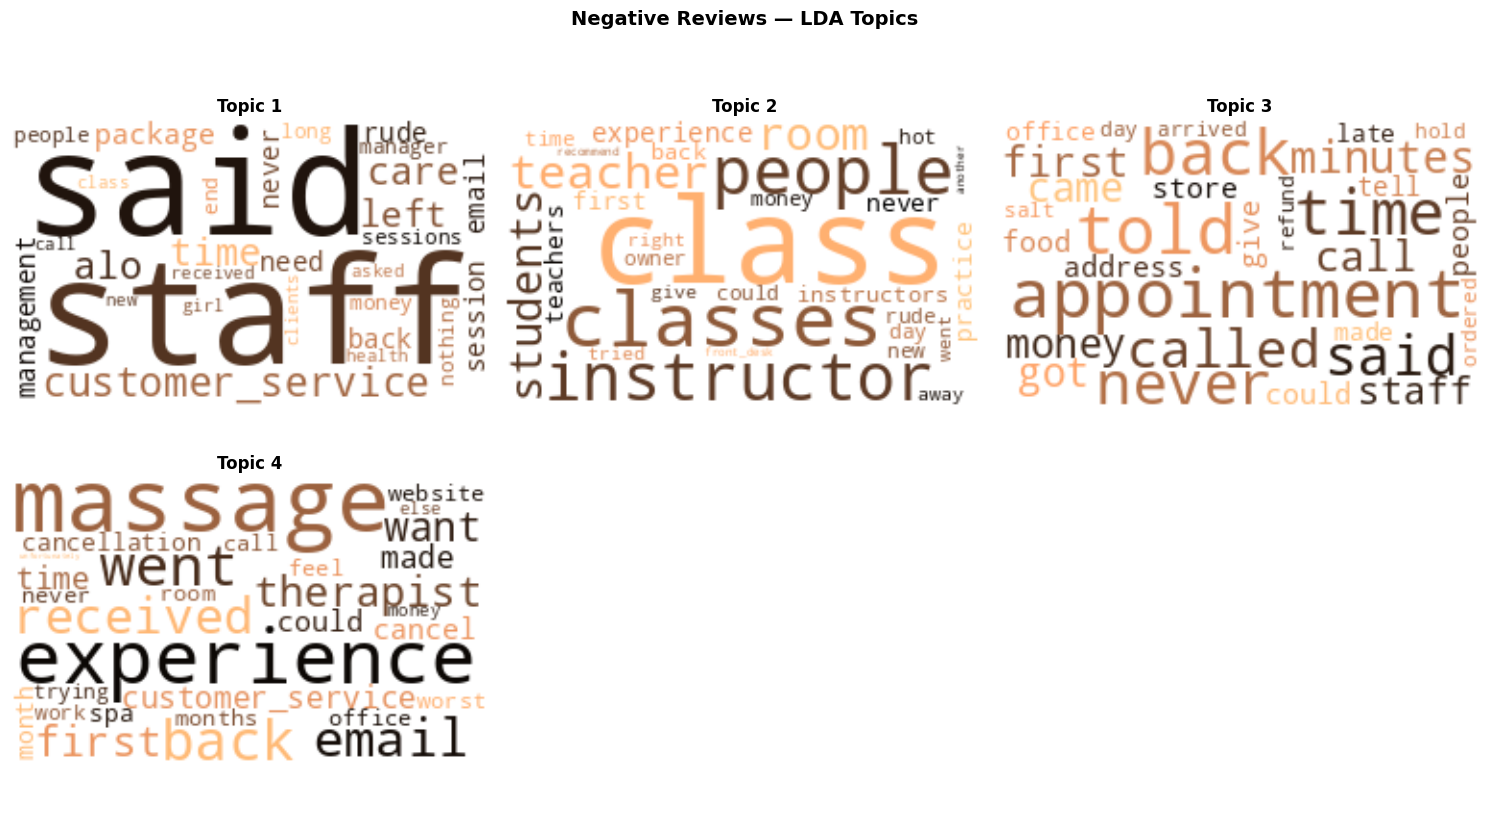

In [ ]:
# making topic wordclouds
def plot_topic_wordclouds(model, label, n_words=30):
    n_topics = model.num_topics
    cols = 3
    rows = (n_topics + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()

    for idx in range(n_topics):
        # Get word weights for this topic
        word_weights = dict(
            model.show_topic(idx, topn=n_words)
        )

        wordcloud = WordCloud(
            width=250, height=150,
            background_color='white',
            colormap='copper_r',
            max_words=n_words
        ).generate_from_frequencies(word_weights)

        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'Topic {idx + 1}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')

    # Hide unused subplots
    for idx in range(n_topics, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'{label}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_topic_wordclouds(model_all, 'All Reviews — LDA Topics')
plot_topic_wordclouds(model_pos, 'Positive Reviews — LDA Topics')
plot_topic_wordclouds(model_neg, 'Negative Reviews — LDA Topics')

## Topic interpretation and business insights

### What drives positive experiences (Topics 1-6, positive corpus)
1. **Hot yoga and fitness** — energetic classes with good music and instructors
2. **Class variety and scheduling** — flexible timetables, multiple levels, convenient parking
3. **First visit and amenities** — strong first impressions, food/café offerings
4. **Community and transformation** — sense of belonging, life-changing practice
5. **Therapeutic services** — massage, acupuncture, pain relief
6. **Atmosphere and service** — clean, friendly, welcoming environment

### What drives negative experiences (Topics 1-4, negative corpus)
1. **Rude staff and management failures** - staff, customer_service, rude, management, care, package, sessions, money, manager
2. **Poor class quality and instructions** - class, instructor, teacher, room, students, practice, hot, rude, front_desk, owner
3. **Booking, appointments and refund disputes** - appointment, told, never, called, minutes, money, refund, late, arrived, address
4. **Wellness service failures** - massage, therapist, cancel, cancellation, spa, website, worst, unfortunately, months

### Insights
The positive corpus shows no topics about pricing or cancellation —
these only emerge in negative reviews. Conversely, community and
transformation themes dominate positive reviews but are absent from
negative ones. This asymmetry suggests that studios succeed or fail
on entirely different dimensions: **success is about experience and
community, failure is about operations and administration.**

**Tips for studio owners:** delivering a great class experience
is necessary but not sufficient. Operational failures — billing disputes,
cancellation policies, front desk attitude — are the primary drivers
of negative reviews and likely of studio closure.

## Save

Save all three trained models and the review dataset enriched with
dominant topic assignments for use in the classifier notebook.

In [ ]:
# Save all three models
model_all.save(os.path.join(PROJECT_DIR, 'lda_model_all.pkl'))
model_pos.save(os.path.join(PROJECT_DIR, 'lda_model_positive.pkl'))
model_neg.save(os.path.join(PROJECT_DIR, 'lda_model_negative.pkl'))

# Save dominant topic per review for use in classifier
def get_dominant_topic(model, corpus):
    dominant_topics = []
    for bow in corpus:
        topics = model.get_document_topics(bow)
        dominant = max(topics, key=lambda x: x[1])[0] if topics else -1
        dominant_topics.append(dominant)
    return dominant_topics

reviews['dominant_topic_all'] = get_dominant_topic(model_all, corpus_all)

# Save enriched reviews
reviews.to_pickle(os.path.join(PROJECT_DIR, 'yoga_reviews_topics.pkl'))
yoga_meta.to_pickle(os.path.join(PROJECT_DIR, 'yoga_studios_meta.pkl'))

print('Saved: 3 LDA models, enriched reviews with dominant topics')